In [2]:
# Imports, reproducibility seed, output folder for report figures (.jpg), and hardware check
import os, re, glob, time, zipfile, shutil, random, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
warnings.filterwarnings("ignore")

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); tf.random.set_seed(s)
set_seed()

INPUT_DIR = "/kaggle/input"
WORK_DIR = "/kaggle/working"
FIG_DIR = f"{WORK_DIR}/figures"
os.makedirs(FIG_DIR, exist_ok=True)
def save_fig(name):
    plt.savefig(f"{FIG_DIR}/{name}.jpg", dpi=200, bbox_inches="tight")

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# Locate UCI HAR raw inertial signals in attached Kaggle inputs; if absent, download and extract from the UCI repository
def find_har_root():
    hits = glob.glob(f"{INPUT_DIR}/**/body_acc_x_train.txt", recursive=True) + \
           glob.glob(f"{WORK_DIR}/har_raw/**/body_acc_x_train.txt", recursive=True)
    return os.path.dirname(os.path.dirname(os.path.dirname(hits[0]))) if hits else None

HAR_ROOT = find_har_root()
if HAR_ROOT is None:
    url = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
    outer = f"{WORK_DIR}/har_outer.zip"
    print("Downloading UCI HAR from", url)
    urllib.request.urlretrieve(url, outer)
    with zipfile.ZipFile(outer) as z:
        z.extractall(f"{WORK_DIR}/har_raw")
    for inner in glob.glob(f"{WORK_DIR}/har_raw/**/*.zip", recursive=True):
        with zipfile.ZipFile(inner) as z:
            z.extractall(f"{WORK_DIR}/har_raw")
    os.remove(outer)
    HAR_ROOT = find_har_root()

print("HAR root:", HAR_ROOT)
print("Contents:", sorted(os.listdir(HAR_ROOT)))

HAR root: /kaggle/working/har_raw/UCI HAR Dataset
Contents: ['.DS_Store', 'README.txt', 'activity_labels.txt', 'features.txt', 'features_info.txt', 'test', 'train']


In [4]:
# Load the 9 raw inertial channels as (N, 128, 9) tensors with 0-indexed labels and subject IDs; pool the official train/test files
SIGNALS = ["body_acc_x", "body_acc_y", "body_acc_z",
           "body_gyro_x", "body_gyro_y", "body_gyro_z",
           "total_acc_x", "total_acc_y", "total_acc_z"]
CLASS_NAMES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]
SHORT_NAMES = ["WALK", "UP", "DOWN", "SIT", "STAND", "LAY"]
NUM_CLASSES = len(CLASS_NAMES)

def read_txt(path):
    return pd.read_csv(path, sep=r"\s+", header=None).values

def load_split(split):
    X = np.stack([read_txt(f"{HAR_ROOT}/{split}/Inertial Signals/{s}_{split}.txt") for s in SIGNALS], axis=-1)
    y = read_txt(f"{HAR_ROOT}/{split}/y_{split}.txt").ravel() - 1
    subj = read_txt(f"{HAR_ROOT}/{split}/subject_{split}.txt").ravel()
    return X.astype("float32"), y.astype("int64"), subj

Xa, ya, sa = load_split("train")
Xb, yb, sb = load_split("test")
X_all = np.concatenate([Xa, Xb])
y_all = np.concatenate([ya, yb])
subj_all = np.concatenate([sa, sb])
print("Pooled raw tensor:", X_all.shape, "| labels:", y_all.shape, "| unique subjects:", len(np.unique(subj_all)))

Pooled raw tensor: (10299, 128, 9) | labels: (10299,) | unique subjects: 30


In [5]:
# Subject-wise 70/15/15 split (no subject appears in two splits, so 50%-overlapping windows cannot leak), then optional stratified subsetting
MAX_WINDOWS = 3000   # lab-recommended subset size; set to None to use all ~10,299 windows

rng = np.random.RandomState(SEED)
subjects = rng.permutation(np.unique(subj_all))
n_tr = int(round(0.70 * len(subjects)))
n_va = int(round(0.15 * len(subjects)))
tr_subj, va_subj, te_subj = subjects[:n_tr], subjects[n_tr:n_tr + n_va], subjects[n_tr + n_va:]

def take(subj_list):
    m = np.isin(subj_all, subj_list)
    return X_all[m], y_all[m]

X_train, y_train = take(tr_subj)
X_val, y_val = take(va_subj)
X_test, y_test = take(te_subj)

if MAX_WINDOWS is not None:
    frac = MAX_WINDOWS / len(X_all)
    def subsample(X, y):
        Xs, _, ys, _ = train_test_split(X, y, train_size=frac, stratify=y, random_state=SEED)
        return Xs, ys
    X_train, y_train = subsample(X_train, y_train)
    X_val, y_val = subsample(X_val, y_val)
    X_test, y_test = subsample(X_test, y_test)

print("Train subjects:", sorted(tr_subj.tolist()))
print("Val subjects  :", sorted(va_subj.tolist()))
print("Test subjects :", sorted(te_subj.tolist()))

Train subjects: [1, 2, 3, 4, 5, 6, 9, 10, 12, 13, 14, 16, 17, 18, 22, 23, 24, 25, 26, 28, 29]
Val subjects  : [19, 21, 27, 30]
Test subjects : [7, 8, 11, 15, 20]


In [6]:
# Per-channel z-score normalisation using training statistics only; print the required tensor shapes and class distribution
mu = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)
sd = X_train.reshape(-1, X_train.shape[-1]).std(axis=0) + 1e-8
X_train_n = (X_train - mu) / sd
X_val_n = (X_val - mu) / sd
X_test_n = (X_test - mu) / sd
T_FULL, F = X_train.shape[1], X_train.shape[2]

print("Input tensor shape:")
print(f"Training   : {X_train_n.shape}")
print(f"Validation : {X_val_n.shape}")
print(f"Testing    : {X_test_n.shape}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Number of features per time step: {F}")
print(f"Sequence length: {T_FULL}\n")

dist = pd.DataFrame({name: np.bincount(y, minlength=NUM_CLASSES) for name, y in
                     [("Train", y_train), ("Val", y_val), ("Test", y_test)]}, index=CLASS_NAMES)
dist.loc["TOTAL"] = dist.sum()
print("Class distribution:")
display(dist)

Input tensor shape:
Training   : (2092, 128, 9)
Validation : (444, 128, 9)
Testing    : (462, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class distribution:


,Train,Val,Test
WALKING,357,66,78
WALKING_UPSTAIRS,319,59,71
WALKING_DOWNSTAIRS,291,55,64
SITTING,354,84,79
STANDING,386,88,82
LAYING,385,92,88
TOTAL,2092,444,462


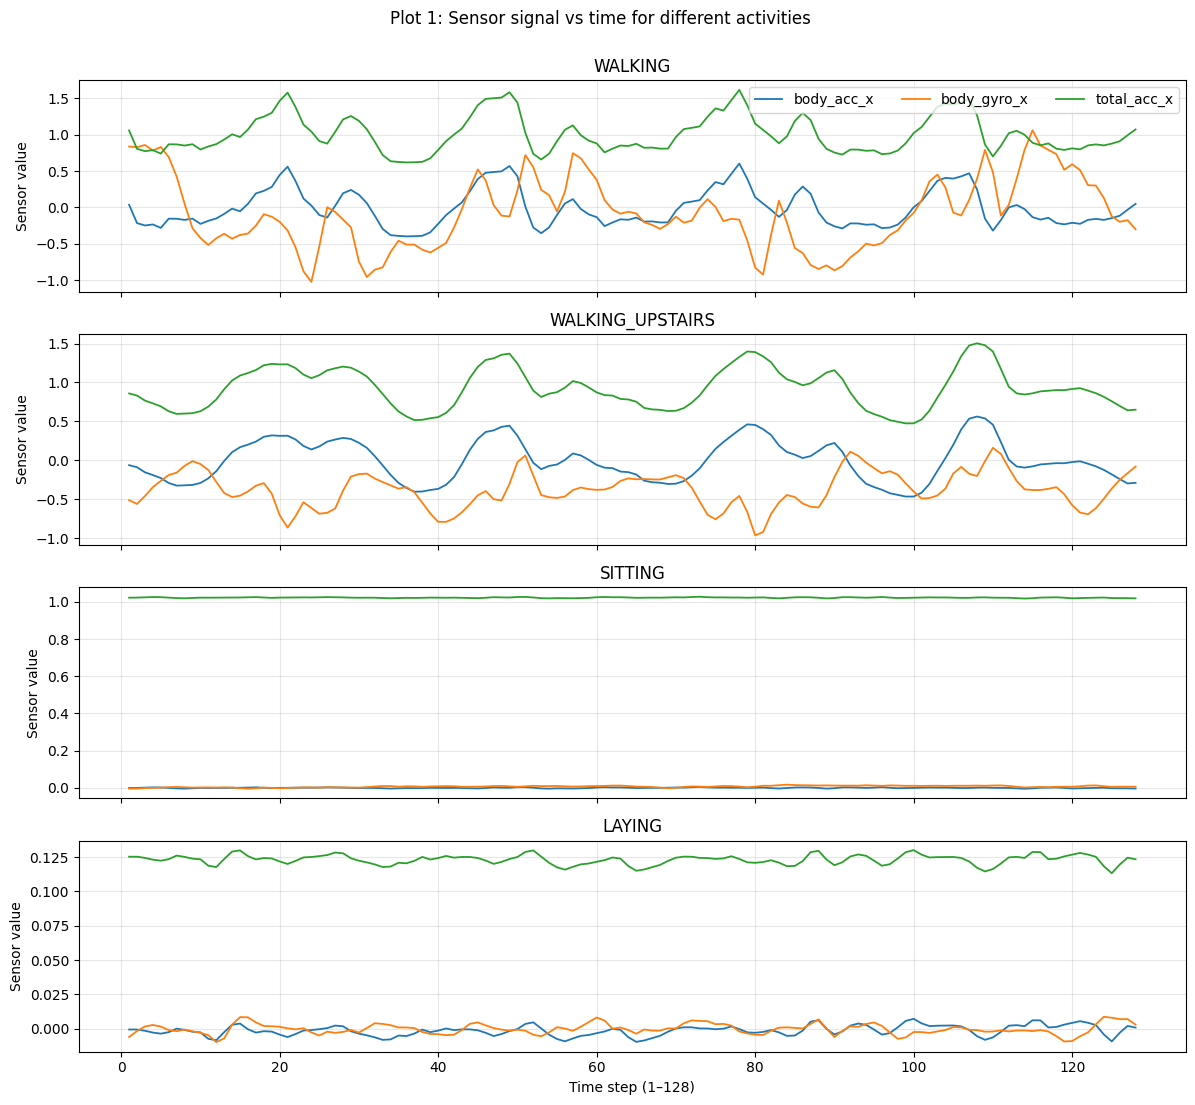

In [7]:
# Plot 1: raw sensor value vs time step for one window from each of four activities (three representative channels)
show_classes = [0, 1, 3, 5]
show_channels = [0, 3, 6]
t_axis = np.arange(1, T_FULL + 1)
fig, axes = plt.subplots(len(show_classes), 1, figsize=(12, 11), sharex=True)
for ax, c in zip(axes, show_classes):
    idx = np.where(y_train == c)[0][0]
    for ch in show_channels:
        ax.plot(t_axis, X_train[idx, :, ch], label=SIGNALS[ch], lw=1.3)
    ax.set_title(CLASS_NAMES[c]); ax.set_ylabel("Sensor value"); ax.grid(alpha=0.3)
axes[0].legend(loc="upper right", ncol=3)
axes[-1].set_xlabel("Time step (1–128)")
fig.suptitle("Plot 1: Sensor signal vs time for different activities", y=1.0)
plt.tight_layout(); save_fig("plot1_sensor_signals"); plt.show()

In [8]:
# Numerical exercise: manual h1, h2, h3 for the scalar RNN vs a Keras SimpleRNN loaded with the same fixed weights
x_seq = np.array([0.5, 0.7, 0.2], dtype="float32")
Wx, Wh, b = 0.5, 0.8, 0.1

h, manual = 0.0, []
for t, x in enumerate(x_seq, start=1):
    pre = Wx * x + Wh * h + b
    h = np.tanh(pre)
    manual.append(h)
    print(f"t={t}: Wx*x{t} + Wh*h{t-1} + b = {Wx}*{x:.1f} + {Wh}*{0 if t == 1 else manual[t-2]:.5f} + {b} = {pre:.5f}  ->  h{t} = tanh({pre:.5f}) = {h:.5f}")

rnn_check = keras.Sequential([keras.Input((3, 1)), layers.SimpleRNN(1, activation="tanh", return_sequences=True)])
rnn_check.layers[0].set_weights([np.array([[Wx]]), np.array([[Wh]]), np.array([b])])
prog = rnn_check.predict(x_seq.reshape(1, 3, 1), verbose=0).ravel()

check = pd.DataFrame({"t": [1, 2, 3], "Manual h_t": manual, "Keras SimpleRNN h_t": prog,
                      "Abs. difference": np.abs(np.array(manual) - prog)})
display(check.round(6))

d31 = Wh * (1 - manual[2] ** 2) * Wh * (1 - manual[1] ** 2)
print(f"BPTT factor dh3/dh1 = Wh(1-h3²) · Wh(1-h2²) = {d31:.5f}  (each step multiplies by a factor < 1 here, so gradients shrink with distance)")

t=1: Wx*x1 + Wh*h0 + b = 0.5*0.5 + 0.8*0.00000 + 0.1 = 0.35000  ->  h1 = tanh(0.35000) = 0.33638
t=2: Wx*x2 + Wh*h1 + b = 0.5*0.7 + 0.8*0.33638 + 0.1 = 0.71910  ->  h2 = tanh(0.71910) = 0.61635
t=3: Wx*x3 + Wh*h2 + b = 0.5*0.2 + 0.8*0.61635 + 0.1 = 0.69308  ->  h3 = tanh(0.69308) = 0.59996


I0000 00:00:1790177346.508992      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790177346.512173      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1790177348.514805     141 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


,t,Manual h_t,Keras SimpleRNN h_t,Abs. difference
0,1,0.336376,0.336376,0.0
1,2,0.616352,0.616352,0.0
2,3,0.599958,0.599958,0.0


BPTT factor dh3/dh1 = Wh(1-h3²) · Wh(1-h2²) = 0.25402  (each step multiplies by a factor < 1 here, so gradients shrink with distance)


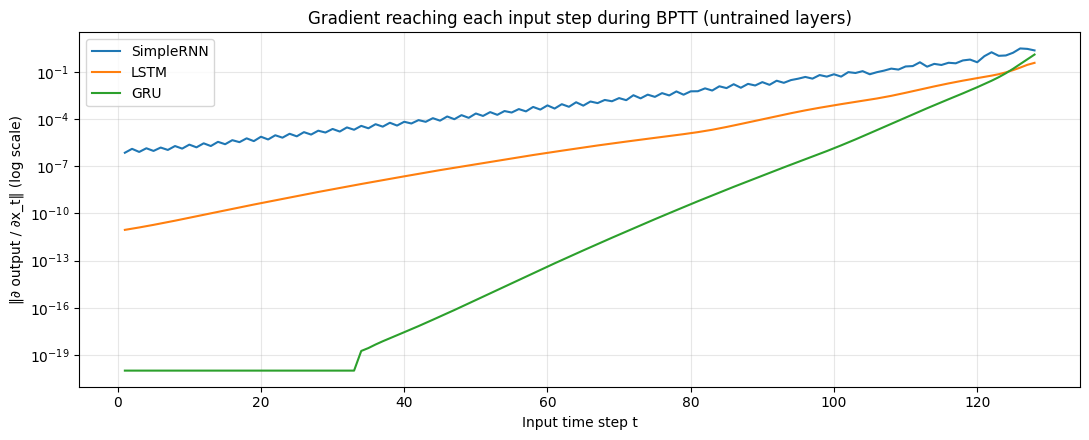

In [9]:
# (Supporting BPTT visual) gradient magnitude |∂(output)/∂x_t| across the 128 steps for untrained SimpleRNN vs LSTM vs GRU
x_probe = tf.convert_to_tensor(X_train_n[:1])
fig, ax = plt.subplots(figsize=(11, 4.5))
for name, Layer in [("SimpleRNN", layers.SimpleRNN), ("LSTM", layers.LSTM), ("GRU", layers.GRU)]:
    set_seed()
    layer = Layer(32)
    with tf.GradientTape() as tape:
        tape.watch(x_probe)
        target = tf.reduce_sum(layer(x_probe))
    g = tf.norm(tape.gradient(target, x_probe)[0], axis=-1).numpy()
    ax.semilogy(t_axis, g + 1e-20, label=name, lw=1.5)
ax.set(xlabel="Input time step t", ylabel="‖∂ output / ∂x_t‖ (log scale)",
       title="Gradient reaching each input step during BPTT (untrained layers)")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); save_fig("plot_extra_bptt_gradient_decay"); plt.show()

In [10]:
# Shared classifier builder (only the recurrent layer changes), common fit/evaluate routine, and a GPU warm-up so the first timed model is not penalised
RNN_LAYERS = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}
UNITS, EPOCHS, BATCH, LR = 32, 30, 32, 1e-3

def build_model(kind, T=None, units=UNITS, stacked=False, bidir=False):
    set_seed()
    T = T or T_FULL
    def rec(return_seq):
        l = RNN_LAYERS[kind](units, return_sequences=return_seq)
        return layers.Bidirectional(l) if bidir else l
    stack = [keras.Input((T, F))] + ([rec(True)] if stacked else []) + [
        rec(False), layers.Dropout(0.2), layers.Dense(16, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax")]
    m = keras.Sequential(stack, name=kind)
    m.compile(optimizer=keras.optimizers.Adam(LR), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

def n_trainable(m):
    return int(sum(np.prod(w.shape) for w in m.trainable_weights))

def fit_eval(m, Xtr, ytr, Xva, yva, Xte, yte, epochs=EPOCHS, batch=BATCH, verbose=0):
    t0 = time.time()
    hist = m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=epochs, batch_size=batch, verbose=verbose)
    train_time = time.time() - t0
    y_pred = m.predict(Xte, verbose=0).argmax(1)
    p, r, f1, _ = precision_recall_fscore_support(yte, y_pred, average="macro", zero_division=0)
    res = {"Accuracy (%)": 100 * accuracy_score(yte, y_pred), "Macro Precision (%)": 100 * p,
           "Macro Recall (%)": 100 * r, "Macro F1 (%)": 100 * f1,
           "Parameters": n_trainable(m), "Training Time (s)": train_time}
    return hist.history, y_pred, res

def train_eval(kind, T=None, verbose=0, **kw):
    T = T or T_FULL
    m = build_model(kind, T=T, **kw)
    hist, y_pred, res = fit_eval(m, X_train_n[:, :T], y_train, X_val_n[:, :T], y_val,
                                 X_test_n[:, :T], y_test, verbose=verbose)
    return m, hist, y_pred, res

for k in RNN_LAYERS:
    build_model(k).fit(X_train_n[:256], y_train[:256], epochs=1, batch_size=BATCH, verbose=0)
models, histories, preds, results = {}, {}, {}, {}
print("Warm-up complete. Identical settings for all models:",
      dict(units=UNITS, epochs=EPOCHS, batch=BATCH, lr=LR, optimizer="Adam", dropout=0.2))

Warm-up complete. Identical settings for all models: {'units': 32, 'epochs': 30, 'batch': 32, 'lr': 0.001, 'optimizer': 'Adam', 'dropout': 0.2}


In [11]:
# Architecture summaries of the three models (same head, only the recurrent layer differs)
for k in RNN_LAYERS:
    build_model(k).summary()

Model: "RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train and evaluate the Vanilla RNN (SimpleRNN, 32 units)
models["RNN"], histories["RNN"], preds["RNN"], results["RNN"] = train_eval("RNN", verbose=2)
print(pd.Series(results["RNN"]).round(3))

Epoch 1/30
66/66 - 7s - 99ms/step - accuracy: 0.3991 - loss: 1.5781 - val_accuracy: 0.5450 - val_loss: 1.2879
Epoch 2/30
66/66 - 1s - 11ms/step - accuracy: 0.5402 - loss: 1.1897 - val_accuracy: 0.6126 - val_loss: 0.9827
Epoch 3/30
66/66 - 1s - 11ms/step - accuracy: 0.5846 - loss: 1.0080 - val_accuracy: 0.6104 - val_loss: 0.9701
Epoch 4/30
66/66 - 1s - 11ms/step - accuracy: 0.6033 - loss: 0.9141 - val_accuracy: 0.6577 - val_loss: 0.7819
Epoch 5/30
66/66 - 1s - 11ms/step - accuracy: 0.6272 - loss: 0.8014 - val_accuracy: 0.6757 - val_loss: 0.7048
Epoch 6/30
66/66 - 1s - 11ms/step - accuracy: 0.6410 - loss: 0.7495 - val_accuracy: 0.6937 - val_loss: 0.6734
Epoch 7/30
66/66 - 1s - 11ms/step - accuracy: 0.6515 - loss: 0.7273 - val_accuracy: 0.6937 - val_loss: 0.6623
Epoch 8/30
66/66 - 1s - 11ms/step - accuracy: 0.6272 - loss: 0.8045 - val_accuracy: 0.6869 - val_loss: 0.7107
Epoch 9/30
66/66 - 1s - 11ms/step - accuracy: 0.6487 - loss: 0.7308 - val_accuracy: 0.7072 - val_loss: 0.6260
Epoch 10/3

In [13]:
# Train and evaluate the LSTM (32 units)
models["LSTM"], histories["LSTM"], preds["LSTM"], results["LSTM"] = train_eval("LSTM", verbose=2)
print(pd.Series(results["LSTM"]).round(3))

Epoch 1/30
66/66 - 2s - 35ms/step - accuracy: 0.3877 - loss: 1.5779 - val_accuracy: 0.4955 - val_loss: 1.2858
Epoch 2/30
66/66 - 1s - 10ms/step - accuracy: 0.5416 - loss: 1.1562 - val_accuracy: 0.6937 - val_loss: 0.8540
Epoch 3/30
66/66 - 1s - 10ms/step - accuracy: 0.5980 - loss: 0.9769 - val_accuracy: 0.6824 - val_loss: 0.8208
Epoch 4/30
66/66 - 1s - 11ms/step - accuracy: 0.6228 - loss: 0.8472 - val_accuracy: 0.6869 - val_loss: 0.6777
Epoch 5/30
66/66 - 1s - 10ms/step - accuracy: 0.6788 - loss: 0.7455 - val_accuracy: 0.7680 - val_loss: 0.6153
Epoch 6/30
66/66 - 1s - 10ms/step - accuracy: 0.6931 - loss: 0.7606 - val_accuracy: 0.7500 - val_loss: 0.6414
Epoch 7/30
66/66 - 1s - 10ms/step - accuracy: 0.7309 - loss: 0.6463 - val_accuracy: 0.8041 - val_loss: 0.5496
Epoch 8/30
66/66 - 1s - 11ms/step - accuracy: 0.7825 - loss: 0.5386 - val_accuracy: 0.8671 - val_loss: 0.4598
Epoch 9/30
66/66 - 1s - 10ms/step - accuracy: 0.8131 - loss: 0.4759 - val_accuracy: 0.9032 - val_loss: 0.3704
Epoch 10/3

In [14]:
# Train and evaluate the GRU (32 units)
models["GRU"], histories["GRU"], preds["GRU"], results["GRU"] = train_eval("GRU", verbose=2)
print(pd.Series(results["GRU"]).round(3))

Epoch 1/30
66/66 - 2s - 35ms/step - accuracy: 0.3848 - loss: 1.6000 - val_accuracy: 0.5248 - val_loss: 1.3503
Epoch 2/30
66/66 - 1s - 10ms/step - accuracy: 0.5301 - loss: 1.3321 - val_accuracy: 0.5743 - val_loss: 1.1570
Epoch 3/30
66/66 - 1s - 10ms/step - accuracy: 0.5817 - loss: 1.0952 - val_accuracy: 0.6982 - val_loss: 0.7684
Epoch 4/30
66/66 - 1s - 10ms/step - accuracy: 0.6802 - loss: 0.7925 - val_accuracy: 0.7342 - val_loss: 0.5609
Epoch 5/30
66/66 - 1s - 10ms/step - accuracy: 0.7361 - loss: 0.6296 - val_accuracy: 0.8108 - val_loss: 0.4459
Epoch 6/30
66/66 - 1s - 10ms/step - accuracy: 0.7782 - loss: 0.5298 - val_accuracy: 0.8671 - val_loss: 0.3706
Epoch 7/30
66/66 - 1s - 10ms/step - accuracy: 0.8212 - loss: 0.4418 - val_accuracy: 0.9054 - val_loss: 0.2888
Epoch 8/30
66/66 - 1s - 10ms/step - accuracy: 0.8403 - loss: 0.4094 - val_accuracy: 0.9167 - val_loss: 0.2637
Epoch 9/30
66/66 - 1s - 10ms/step - accuracy: 0.8733 - loss: 0.3374 - val_accuracy: 0.9324 - val_loss: 0.2199
Epoch 10/3

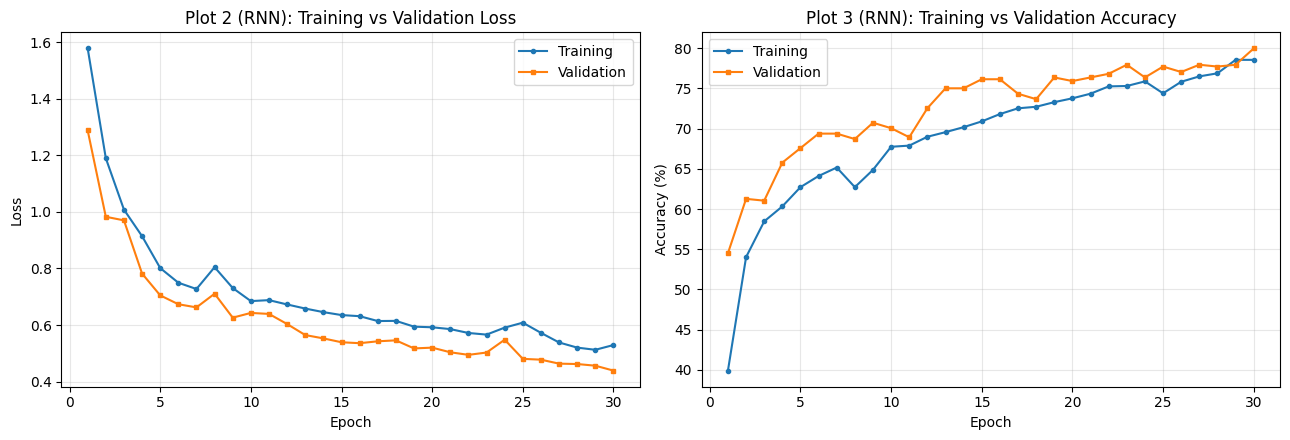

RNN: final train acc 78.54% | final val acc 79.95% | best val acc 79.95% @ epoch 30 | min val loss @ epoch 30 | final gap -1.42 pts



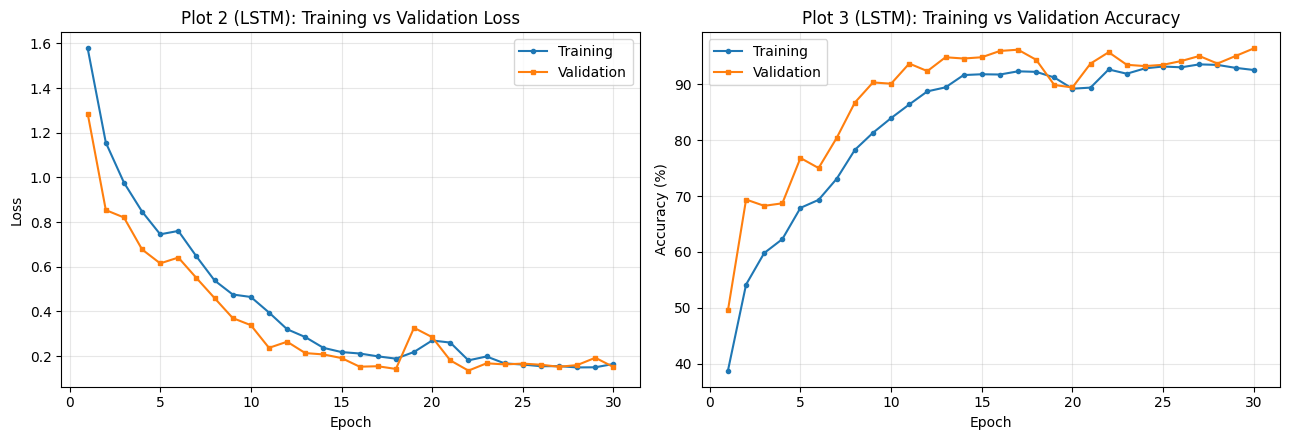

LSTM: final train acc 92.54% | final val acc 96.40% | best val acc 96.40% @ epoch 30 | min val loss @ epoch 22 | final gap -3.85 pts



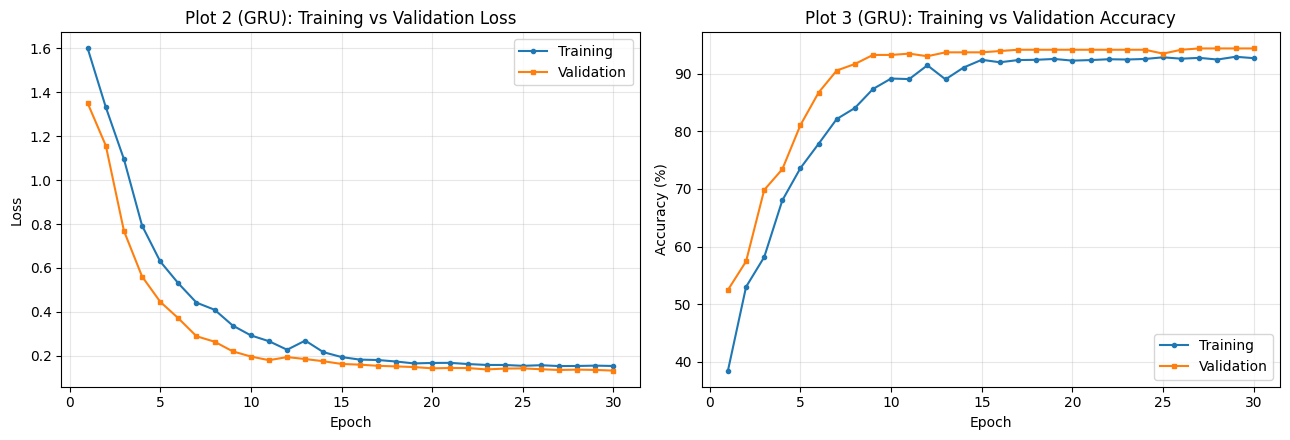

GRU: final train acc 92.69% | final val acc 94.37% | best val acc 94.37% @ epoch 27 | min val loss @ epoch 30 | final gap -1.68 pts



In [15]:
# Plots 2 & 3: training/validation loss and accuracy per model, with best-epoch and generalisation-gap summary
for k in RNN_LAYERS:
    hst = histories[k]
    ep = np.arange(1, len(hst["loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    ax[0].plot(ep, hst["loss"], "o-", ms=3, label="Training")
    ax[0].plot(ep, hst["val_loss"], "s-", ms=3, label="Validation")
    ax[0].set(title=f"Plot 2 ({k}): Training vs Validation Loss", xlabel="Epoch", ylabel="Loss")
    ax[1].plot(ep, 100 * np.array(hst["accuracy"]), "o-", ms=3, label="Training")
    ax[1].plot(ep, 100 * np.array(hst["val_accuracy"]), "s-", ms=3, label="Validation")
    ax[1].set(title=f"Plot 3 ({k}): Training vs Validation Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
    for a in ax:
        a.legend(); a.grid(alpha=0.3)
    plt.tight_layout(); save_fig(f"plot2_3_curves_{k.lower()}"); plt.show()
    best_ep = int(np.argmax(hst["val_accuracy"])) + 1
    min_vl_ep = int(np.argmin(hst["val_loss"])) + 1
    gap = 100 * (hst["accuracy"][-1] - hst["val_accuracy"][-1])
    print(f"{k}: final train acc {100*hst['accuracy'][-1]:.2f}% | final val acc {100*hst['val_accuracy'][-1]:.2f}% | "
          f"best val acc {100*max(hst['val_accuracy']):.2f}% @ epoch {best_ep} | min val loss @ epoch {min_vl_ep} | "
          f"final gap {gap:.2f} pts\n")

In [16]:
# Test-set performance table (macro-averaged metrics, parameters, training time)
metrics_df = pd.DataFrame(results)[list(RNN_LAYERS)]
display(metrics_df.round(2))

,RNN,LSTM,GRU
Accuracy (%),83.55,94.81,98.48
Macro Precision (%),82.87,95.37,98.65
Macro Recall (%),82.48,95.03,98.50
Macro F1 (%),82.50,94.92,98.53
Parameters,1974.00,6006.00,4758.00
Training Time (s),27.93,22.26,21.69


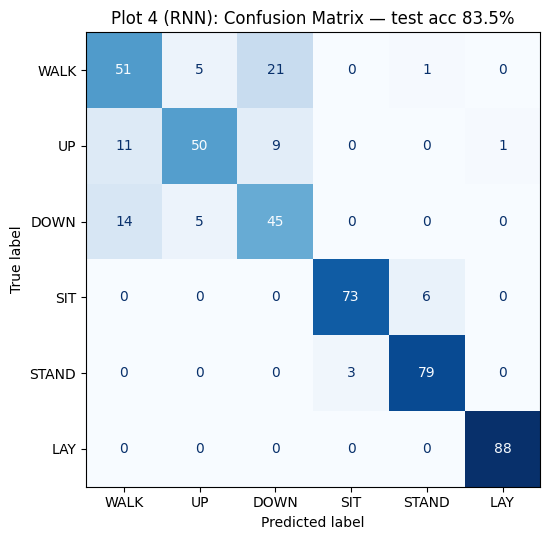

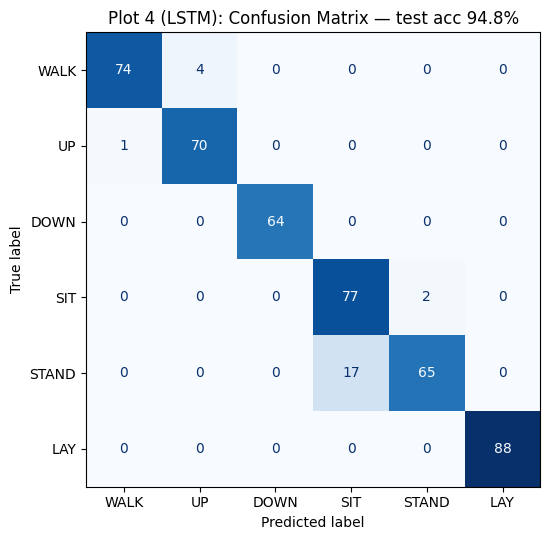

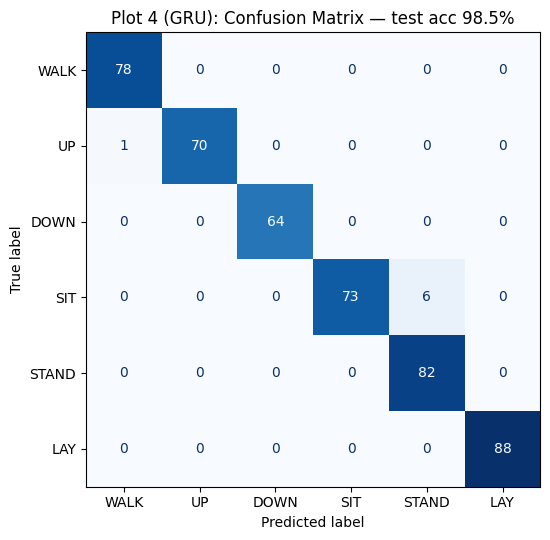

Per-class recall (%):


,RNN,LSTM,GRU
WALKING,65.4,94.9,100.0
WALKING_UPSTAIRS,70.4,98.6,98.6
WALKING_DOWNSTAIRS,70.3,100.0,100.0
SITTING,92.4,97.5,92.4
STANDING,96.3,79.3,100.0
LAYING,100.0,100.0,100.0


RNN: highest recall = LAYING (100.0%) | most misclassified = WALKING (27 errors) | top confusions (true -> predicted): WALKING -> WALKING_DOWNSTAIRS (21); WALKING_DOWNSTAIRS -> WALKING (14); WALKING_UPSTAIRS -> WALKING (11)
LSTM: highest recall = WALKING_DOWNSTAIRS (100.0%) | most misclassified = STANDING (17 errors) | top confusions (true -> predicted): STANDING -> SITTING (17); WALKING -> WALKING_UPSTAIRS (4); SITTING -> STANDING (2)
GRU: highest recall = WALKING (100.0%) | most misclassified = SITTING (6 errors) | top confusions (true -> predicted): SITTING -> STANDING (6); WALKING_UPSTAIRS -> WALKING (1)


In [17]:
# Plot 4: one confusion matrix per model, followed by per-class recall and the dominant confusions read from each matrix
cms = {}
for k in RNN_LAYERS:
    cms[k] = confusion_matrix(y_test, preds[k], labels=range(NUM_CLASSES))
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ConfusionMatrixDisplay(cms[k], display_labels=SHORT_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Plot 4 ({k}): Confusion Matrix — test acc {results[k]['Accuracy (%)']:.1f}%")
    plt.tight_layout(); save_fig(f"plot4_confusion_{k.lower()}"); plt.show()

recall_df = pd.DataFrame({k: 100 * cms[k].diagonal() / cms[k].sum(1).clip(min=1) for k in RNN_LAYERS}, index=CLASS_NAMES)
print("Per-class recall (%):"); display(recall_df.round(1))

for k in RNN_LAYERS:
    off = cms[k].copy(); np.fill_diagonal(off, 0)
    pairs = sorted([(off[i, j], CLASS_NAMES[i], CLASS_NAMES[j]) for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if off[i, j] > 0], reverse=True)[:3]
    print(f"{k}: highest recall = {recall_df[k].idxmax()} ({recall_df[k].max():.1f}%) | "
          f"most misclassified = {CLASS_NAMES[off.sum(1).argmax()]} ({off.sum(1).max()} errors) | "
          f"top confusions (true -> predicted): " + "; ".join(f"{a} -> {b} ({n})" for n, a, b in pairs))

,RNN,LSTM,GRU
Hidden state,Yes,Yes,Yes
Cell state,No,Yes,No
Forget gate,No,Yes,No
Input gate,No,Yes,No
Output gate,No,Yes,No
Update gate,No,No,Yes
Reset gate,No,No,Yes
Parameters,1974,6006,4758
Training time (s),27.9,22.3,21.7
Test F1-score (%),82.50,94.92,98.53


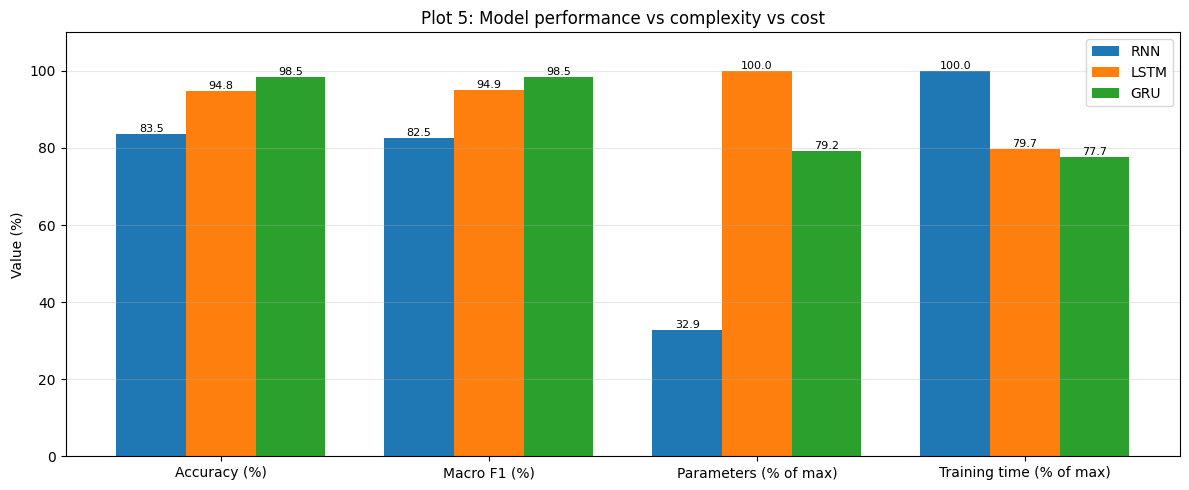

In [18]:
# RNN vs LSTM vs GRU comparison table (gates + measured values) and Plot 5 bar chart (accuracy, F1, normalised parameters and time)
props = ["Hidden state", "Cell state", "Forget gate", "Input gate", "Output gate", "Update gate", "Reset gate"]
gates = {"RNN":  ["Yes", "No", "No", "No", "No", "No", "No"],
         "LSTM": ["Yes", "Yes", "Yes", "Yes", "Yes", "No", "No"],
         "GRU":  ["Yes", "No", "No", "No", "No", "Yes", "Yes"]}
comp = pd.DataFrame(gates, index=props)
comp.loc["Parameters"] = [results[k]["Parameters"] for k in comp.columns]
comp.loc["Training time (s)"] = [f"{results[k]['Training Time (s)']:.1f}" for k in comp.columns]
comp.loc["Test F1-score (%)"] = [f"{results[k]['Macro F1 (%)']:.2f}" for k in comp.columns]
display(comp)

max_p = max(results[k]["Parameters"] for k in RNN_LAYERS)
max_t = max(results[k]["Training Time (s)"] for k in RNN_LAYERS)
labels = ["Accuracy (%)", "Macro F1 (%)", "Parameters (% of max)", "Training time (% of max)"]
x = np.arange(len(labels)); w = 0.26
fig, ax = plt.subplots(figsize=(12, 5))
for i, k in enumerate(RNN_LAYERS):
    vals = [results[k]["Accuracy (%)"], results[k]["Macro F1 (%)"],
            100 * results[k]["Parameters"] / max_p, 100 * results[k]["Training Time (s)"] / max_t]
    bars = ax.bar(x + (i - 1) * w, vals, w, label=k)
    ax.bar_label(bars, fmt="%.1f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("Value (%)"); ax.set_ylim(0, 110)
ax.set_title("Plot 5: Model performance vs complexity vs cost"); ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); save_fig("plot5_model_comparison"); plt.show()

T= 32 | RNN  | Macro F1 = 77.25% | train time = 18.3s
T= 32 | LSTM | Macro F1 = 93.44% | train time = 17.2s
T= 32 | GRU  | Macro F1 = 95.17% | train time = 17.3s
T= 64 | RNN  | Macro F1 = 83.94% | train time = 20.4s
T= 64 | LSTM | Macro F1 = 96.12% | train time = 19.0s
T= 64 | GRU  | Macro F1 = 98.31% | train time = 18.7s
T=128 | RNN  | Macro F1 = 82.50% | train time = 27.9s
T=128 | LSTM | Macro F1 = 94.92% | train time = 22.3s
T=128 | GRU  | Macro F1 = 98.53% | train time = 21.7s

Macro F1 (%) by sequence length:


Model,RNN,LSTM,GRU
Sequence Length,,,
32,77.25,93.44,95.17
64,83.94,96.12,98.31
128,82.50,94.92,98.53


Training time (s) by sequence length:


Model,RNN,LSTM,GRU
Sequence Length,,,
32,18.3,17.2,17.3
64,20.4,19.0,18.7
128,27.9,22.3,21.7


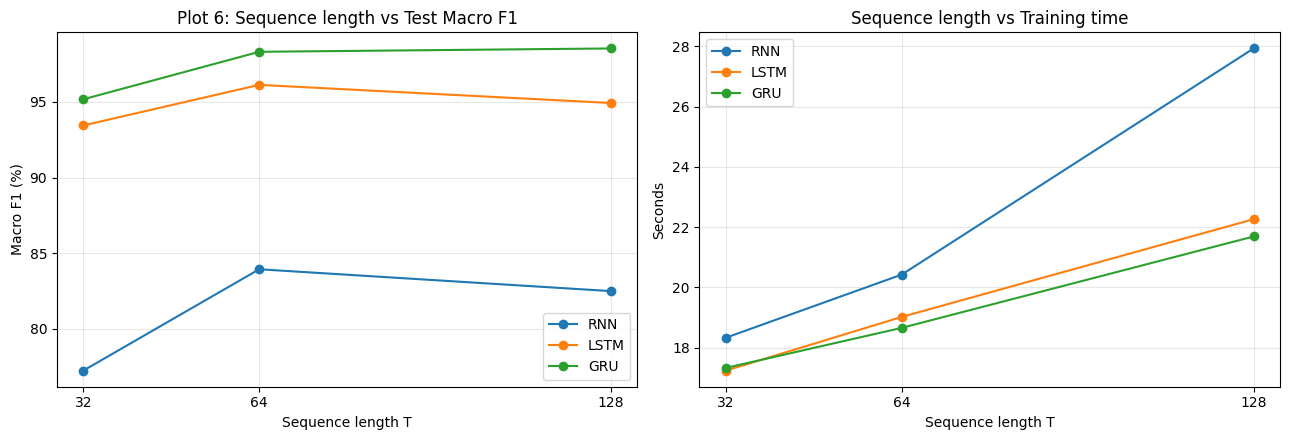

In [19]:
# Sequence-length study: retrain all three models on the first T steps (T = 32, 64, 128) and produce Plot 6 (F1) plus a cost view (time)
SEQ_LENS = [32, 64, 128]
seq_rows = []
for T in SEQ_LENS:
    for k in RNN_LAYERS:
        r = results[k] if T == T_FULL else train_eval(k, T=T)[3]
        seq_rows.append({"Sequence Length": T, "Model": k, "F1": r["Macro F1 (%)"], "Time": r["Training Time (s)"]})
        print(f"T={T:>3} | {k:<4} | Macro F1 = {r['Macro F1 (%)']:.2f}% | train time = {r['Training Time (s)']:.1f}s")
seq_df = pd.DataFrame(seq_rows)
seq_f1 = seq_df.pivot(index="Sequence Length", columns="Model", values="F1")[list(RNN_LAYERS)]
seq_time = seq_df.pivot(index="Sequence Length", columns="Model", values="Time")[list(RNN_LAYERS)]
print("\nMacro F1 (%) by sequence length:"); display(seq_f1.round(2))
print("Training time (s) by sequence length:"); display(seq_time.round(1))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for k in RNN_LAYERS:
    ax[0].plot(SEQ_LENS, seq_f1[k], "o-", label=k)
    ax[1].plot(SEQ_LENS, seq_time[k], "o-", label=k)
ax[0].set(title="Plot 6: Sequence length vs Test Macro F1", xlabel="Sequence length T", ylabel="Macro F1 (%)")
ax[1].set(title="Sequence length vs Training time", xlabel="Sequence length T", ylabel="Seconds")
for a in ax:
    a.set_xticks(SEQ_LENS); a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); save_fig("plot6_sequence_length"); plt.show()

In [20]:
import os, glob, collections
for d in sorted(os.listdir("/kaggle/input")):
    print("INPUT:", d)
    ext = collections.Counter(os.path.splitext(f)[1].lower()
                              for _, _, fs in os.walk(f"/kaggle/input/{d}") for f in fs)
    print("  extensions:", ext.most_common(8))
    sample = glob.glob(f"/kaggle/input/{d}/**/*", recursive=True)[:5]
    print("  sample paths:", [p.replace('/kaggle/input/','') for p in sample], "\n")

INPUT: datasets
  extensions: [('.avi', 13320), ('.txt', 7)]
  sample paths: ['datasets/pevogam', 'datasets/pevogam/ucf101', 'datasets/pevogam/ucf101/UCF101', 'datasets/pevogam/ucf101/UCF101TrainTestSplits-RecognitionTask', 'datasets/pevogam/ucf101/UCF101/UCF-101'] 

INPUT: notebooks
  extensions: [('.png', 7), ('.html', 2), ('.h5', 1), ('.ipynb', 1), ('.json', 1), ('.css', 1)]
  sample paths: ['notebooks/muayad', 'notebooks/muayad/ucf101', 'notebooks/muayad/ucf101/UCF101.h5', 'notebooks/muayad/ucf101/__results__.html', 'notebooks/muayad/ucf101/__resultx__.html'] 



In [21]:
# Find UCF101 clips in attached inputs, keep 5 classes, cap clips per group, and split by group (g01–05 test, g06–09 val, g10–25 train) to avoid same-scene leakage
VIDEO_CLASSES = ["Basketball", "Biking", "TennisSwing", "WalkingWithDog", "JumpingJack"]
MAX_PER_GROUP = 2
N_FRAMES, IMG = 10, 224

pattern = re.compile(r"v_([A-Za-z]+)_g(\d+)_c(\d+)")
all_videos = glob.glob(f"{INPUT_DIR}/**/*.avi", recursive=True) + glob.glob(f"{INPUT_DIR}/**/*.mp4", recursive=True)
print("Total video files found in inputs:", len(all_videos))

rows = []
for p in all_videos:
    m = pattern.search(os.path.basename(p))
    if m and m.group(1) in VIDEO_CLASSES:
        rows.append((p, m.group(1), int(m.group(2)), int(m.group(3))))
assert rows, "No UCF101 clips for the chosen classes were found. Attach a UCF101 dataset via 'Add Input' and re-run."

vid_df = (pd.DataFrame(rows, columns=["path", "label", "group", "clip"])
          .drop_duplicates(subset=["label", "group", "clip"])
          .sort_values(["label", "group", "clip"])
          .groupby(["label", "group"]).head(MAX_PER_GROUP).reset_index(drop=True))
vid_df["split"] = np.where(vid_df.group <= 5, "test", np.where(vid_df.group <= 9, "val", "train"))
print(pd.crosstab(vid_df.label, vid_df.split, margins=True))

Total video files found in inputs: 13320
split           test  train  val  All
label                                
Basketball        10     32    8   50
Biking            10     32    8   50
JumpingJack       10     32    8   50
TennisSwing       10     32    8   50
WalkingWithDog    10     32    8   50
All               50    160   40  250


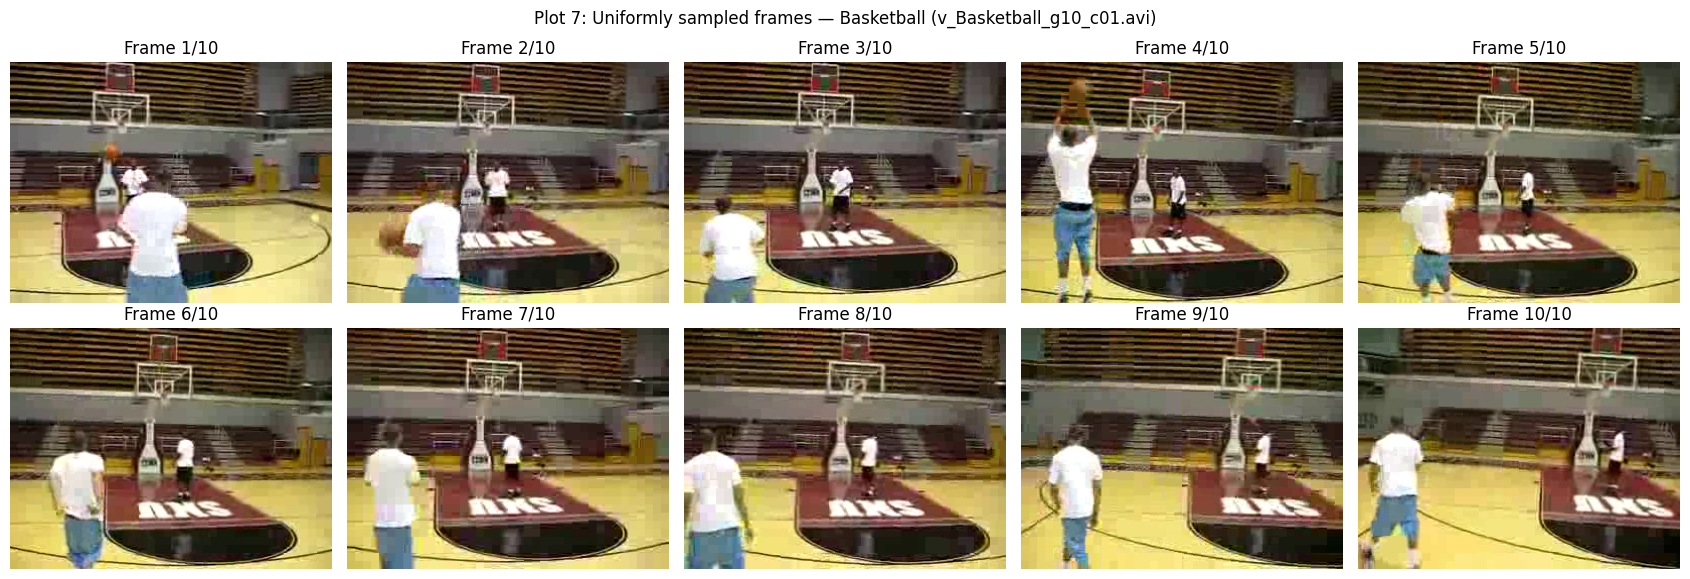

In [22]:
# Uniform 10-frame sampler (RGB, resized to 224×224) and Plot 7: sampled frames from one training video
def sample_frames(path, n=N_FRAMES, size=IMG):
    cap = cv2.VideoCapture(path)
    frames = []
    while True:
        ok, fr = cap.read()
        if not ok:
            break
        frames.append(fr)
    cap.release()
    if not frames:
        return None, None
    idx = np.linspace(0, len(frames) - 1, n).astype(int)
    raw = [cv2.cvtColor(frames[i], cv2.COLOR_BGR2RGB) for i in idx]
    resized = np.stack([cv2.resize(f, (size, size)) for f in raw])
    return resized, raw

demo = vid_df[vid_df.split == "train"].iloc[0]
_, demo_raw = sample_frames(demo.path)
fig, axes = plt.subplots(2, 5, figsize=(17, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(demo_raw[i]); ax.set_title(f"Frame {i + 1}/{N_FRAMES}"); ax.axis("off")
fig.suptitle(f"Plot 7: Uniformly sampled frames — {demo.label} ({os.path.basename(demo.path)})")
plt.tight_layout(); save_fig("plot7_video_frames"); plt.show()

In [23]:
# Frozen ImageNet MobileNetV2 (no head, global average pooling) as feature extractor: every video becomes a (10, D) feature sequence
cnn = keras.applications.MobileNetV2(include_top=False, weights="imagenet", pooling="avg", input_shape=(IMG, IMG, 3))
cnn.trainable = False
D = cnn.output_shape[-1]

feats, vlabels, vsplits, vnames = [], [], [], []
t0 = time.time()
for i, row in enumerate(vid_df.itertuples(), start=1):
    fr, _ = sample_frames(row.path)
    if fr is None:
        continue
    x = keras.applications.mobilenet_v2.preprocess_input(fr.astype("float32"))
    feats.append(cnn(x, training=False).numpy())
    vlabels.append(VIDEO_CLASSES.index(row.label)); vsplits.append(row.split); vnames.append(os.path.basename(row.path))
    if i % 50 == 0:
        print(f"  processed {i}/{len(vid_df)} videos")
FEATS, VLAB, VSPL, VNAME = np.stack(feats), np.array(vlabels), np.array(vsplits), np.array(vnames)
Xv = {s: FEATS[VSPL == s] for s in ["train", "val", "test"]}
yv = {s: VLAB[VSPL == s] for s in ["train", "val", "test"]}
names_test = VNAME[VSPL == "test"]

print(f"\nCNN feature dimension D = {D}")
print(f"Per-frame input: ({IMG}, {IMG}, 3) -> feature vector ({D},)")
print(f"Per-video recurrent input: ({N_FRAMES}, {D})")
for s in ["train", "val", "test"]:
    print(f"{s:<5}: X = {Xv[s].shape}, y = {yv[s].shape}")
print(f"Feature extraction time: {time.time() - t0:.1f}s")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  processed 50/250 videos
  processed 100/250 videos
  processed 150/250 videos
  processed 200/250 videos
  processed 250/250 videos

CNN feature dimension D = 1280
Per-frame input: (224, 224, 3) -> feature vector (1280,)
Per-video recurrent input: (10, 1280)
train: X = (160, 10, 1280), y = (160,)
val  : X = (40, 10, 1280), y = (40,)
test : X = (50, 10, 1280), y = (50,)
Feature extraction time: 52.6s


In [24]:
# Train CNN–LSTM and CNN–GRU heads on identical frozen CNN features (32 recurrent units, dropout, softmax over the 5 actions)
VID_EPOCHS, VID_BATCH = 30, 16
N_VCLASSES = len(VIDEO_CLASSES)

def build_video_model(kind):
    set_seed()
    m = keras.Sequential([keras.Input((N_FRAMES, D)), RNN_LAYERS[kind](32), layers.Dropout(0.3),
                          layers.Dense(N_VCLASSES, activation="softmax")], name=f"CNN_{kind}")
    m.compile(optimizer=keras.optimizers.Adam(LR), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

vmodels, vhist, vpreds, vresults = {}, {}, {}, {}
for k in ["LSTM", "GRU"]:
    print(f"===== CNN–{k} =====")
    vmodels[k] = build_video_model(k)
    vhist[k], vpreds[k], vresults[k] = fit_eval(vmodels[k], Xv["train"], yv["train"], Xv["val"], yv["val"],
                                                Xv["test"], yv["test"], epochs=VID_EPOCHS, batch=VID_BATCH, verbose=2)
vmodels["LSTM"].summary()
display(pd.DataFrame(vresults).round(2))

===== CNN–LSTM =====
Epoch 1/30
10/10 - 2s - 153ms/step - accuracy: 0.3438 - loss: 1.5348 - val_accuracy: 0.5500 - val_loss: 1.3921
Epoch 2/30
10/10 - 0s - 16ms/step - accuracy: 0.7437 - loss: 1.0298 - val_accuracy: 0.7750 - val_loss: 1.0151
Epoch 3/30
10/10 - 0s - 16ms/step - accuracy: 0.8750 - loss: 0.6583 - val_accuracy: 0.8000 - val_loss: 0.6938
Epoch 4/30
10/10 - 0s - 16ms/step - accuracy: 0.9250 - loss: 0.4178 - val_accuracy: 0.8000 - val_loss: 0.6209
Epoch 5/30
10/10 - 0s - 16ms/step - accuracy: 0.9812 - loss: 0.2637 - val_accuracy: 0.8000 - val_loss: 0.6511
Epoch 6/30
10/10 - 0s - 16ms/step - accuracy: 0.9688 - loss: 0.2538 - val_accuracy: 0.7500 - val_loss: 0.5479
Epoch 7/30
10/10 - 0s - 16ms/step - accuracy: 0.9937 - loss: 0.1607 - val_accuracy: 0.7750 - val_loss: 0.5727
Epoch 8/30
10/10 - 0s - 16ms/step - accuracy: 1.0000 - loss: 0.1232 - val_accuracy: 0.8250 - val_loss: 0.4768
Epoch 9/30
10/10 - 0s - 16ms/step - accuracy: 1.0000 - loss: 0.0965 - val_accuracy: 0.8000 - val_l

Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 504,689 (1.93 MB)

 Trainable params: 168,229 (657.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 336,460 (1.28 MB)

,LSTM,GRU
Accuracy (%),88.00,92.00
Macro Precision (%),88.35,91.96
Macro Recall (%),88.00,92.00
Macro F1 (%),87.54,91.89
Parameters,168229.00,126309.00
Training Time (s),6.33,6.25


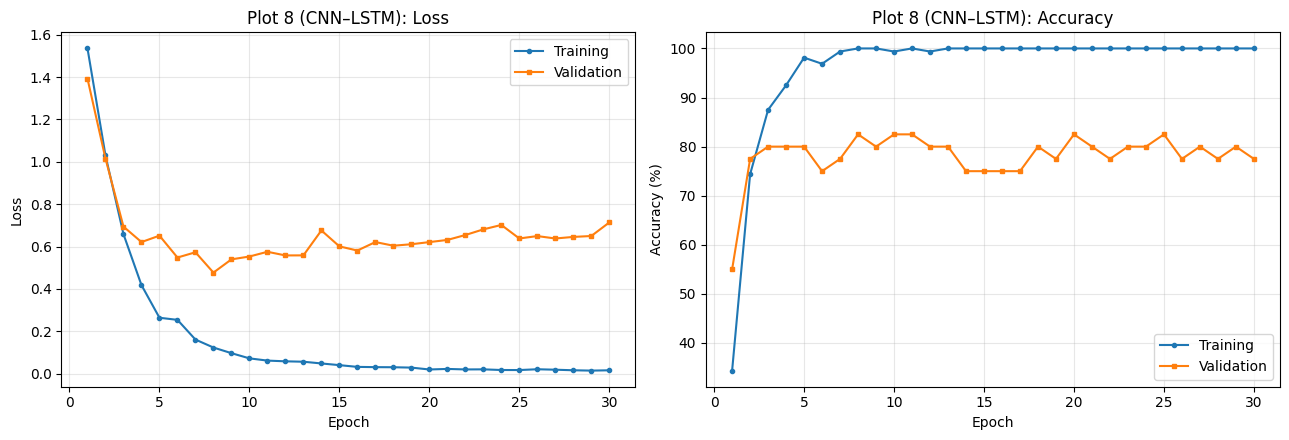

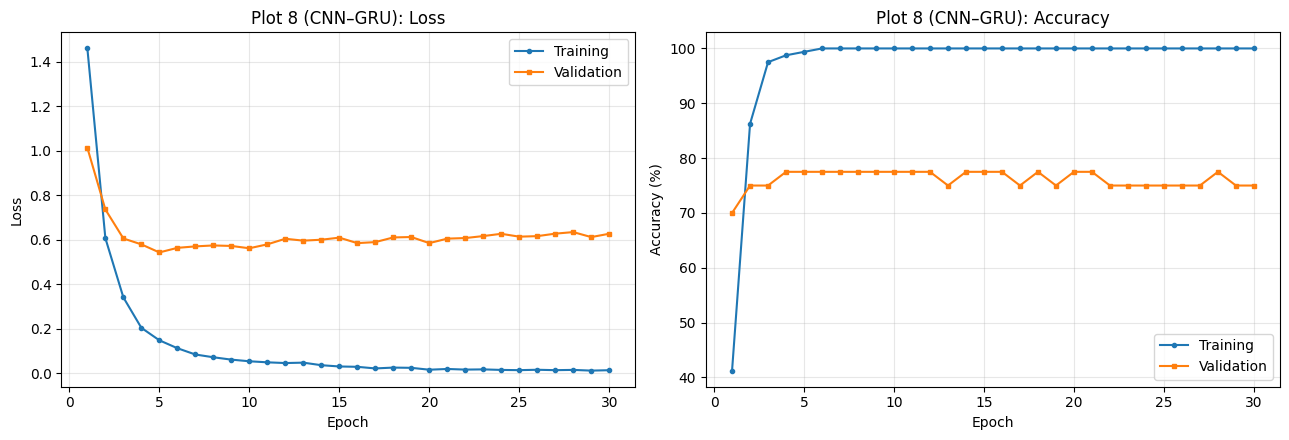

In [25]:
# Plot 8: training/validation loss and accuracy for the video models
for k in vhist:
    hst = vhist[k]; ep = np.arange(1, len(hst["loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    ax[0].plot(ep, hst["loss"], "o-", ms=3, label="Training"); ax[0].plot(ep, hst["val_loss"], "s-", ms=3, label="Validation")
    ax[0].set(title=f"Plot 8 (CNN–{k}): Loss", xlabel="Epoch", ylabel="Loss")
    ax[1].plot(ep, 100 * np.array(hst["accuracy"]), "o-", ms=3, label="Training")
    ax[1].plot(ep, 100 * np.array(hst["val_accuracy"]), "s-", ms=3, label="Validation")
    ax[1].set(title=f"Plot 8 (CNN–{k}): Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
    for a in ax:
        a.legend(); a.grid(alpha=0.3)
    plt.tight_layout(); save_fig(f"plot8_video_curves_cnn_{k.lower()}"); plt.show()

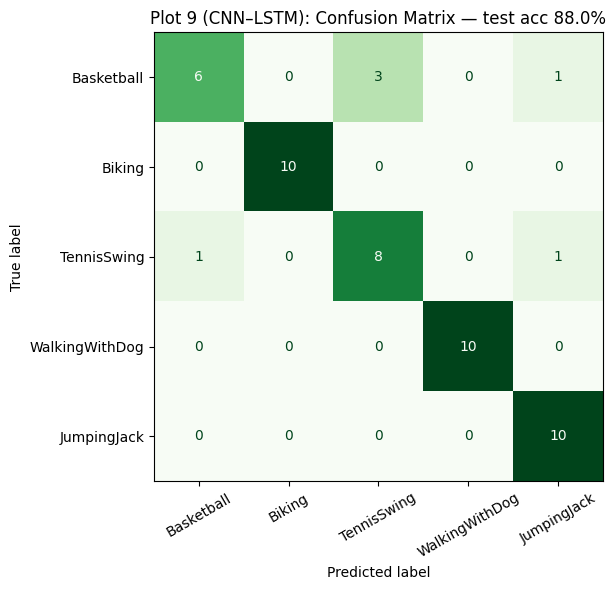

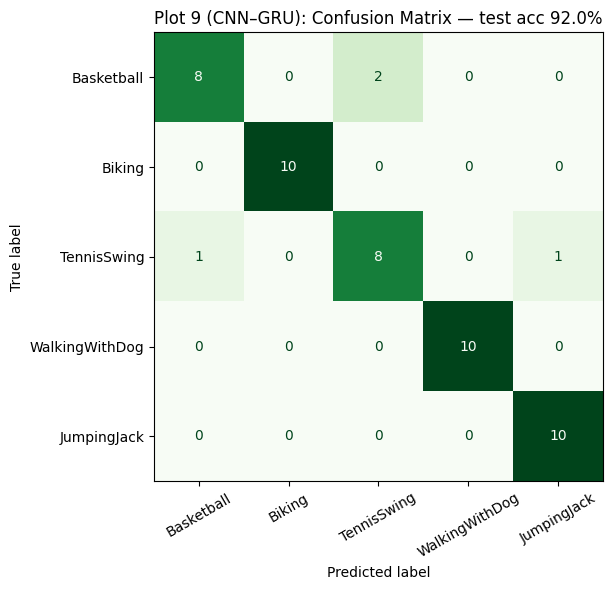

Sample predictions from CNN–GRU:

Video           : v_Biking_g02_c02.avi
Predicted class : Biking
Actual class    : Biking
Confidence      : 1.00

Video           : v_TennisSwing_g05_c02.avi
Predicted class : TennisSwing
Actual class    : TennisSwing
Confidence      : 0.88

Video           : v_TennisSwing_g01_c01.avi
Predicted class : TennisSwing
Actual class    : TennisSwing
Confidence      : 0.97

Video           : v_WalkingWithDog_g03_c02.avi
Predicted class : WalkingWithDog
Actual class    : WalkingWithDog
Confidence      : 0.75

Video           : v_Biking_g04_c02.avi
Predicted class : Biking
Actual class    : Biking
Confidence      : 0.54



In [26]:
# Plot 9: video confusion matrices, then sample test predictions with model-computed confidence
for k in vpreds:
    cm = confusion_matrix(yv["test"], vpreds[k], labels=range(N_VCLASSES))
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(cm, display_labels=VIDEO_CLASSES).plot(ax=ax, cmap="Greens", colorbar=False, xticks_rotation=30)
    ax.set_title(f"Plot 9 (CNN–{k}): Confusion Matrix — test acc {vresults[k]['Accuracy (%)']:.1f}%")
    plt.tight_layout(); save_fig(f"plot9_video_confusion_cnn_{k.lower()}"); plt.show()

best_v = max(vresults, key=lambda k: vresults[k]["Macro F1 (%)"])
probs = vmodels[best_v].predict(Xv["test"], verbose=0)
rng_v = np.random.RandomState(SEED)
print(f"Sample predictions from CNN–{best_v}:\n")
for i in rng_v.choice(len(probs), size=min(5, len(probs)), replace=False):
    print(f"Video           : {names_test[i]}")
    print(f"Predicted class : {VIDEO_CLASSES[probs[i].argmax()]}")
    print(f"Actual class    : {VIDEO_CLASSES[yv['test'][i]]}")
    print(f"Confidence      : {probs[i].max():.2f}\n")

In [27]:
# Synthetic sequence-reversal dataset (token 0 = START) with teacher-forcing decoder inputs and a 70/15/15 split
S2S_LEN, S2S_MAX, S2S_N, START = 8, 30, 12000, 0
VOCAB = S2S_MAX + 1

rng_s = np.random.RandomState(SEED)
src = rng_s.randint(1, S2S_MAX + 1, size=(S2S_N, S2S_LEN))
tgt = src[:, ::-1].copy()
dec_inp = np.concatenate([np.full((S2S_N, 1), START), tgt[:, :-1]], axis=1)

perm = rng_s.permutation(S2S_N)
a, b = int(0.70 * S2S_N), int(0.85 * S2S_N)
s_tr, s_va, s_te = perm[:a], perm[a:b], perm[b:]
print(f"Train/Val/Test sequences: {len(s_tr)}/{len(s_va)}/{len(s_te)} | length {S2S_LEN} | tokens 1..{S2S_MAX}")
for i in range(3):
    print(f"encoder input {src[i].tolist()}  | decoder input (teacher forcing) {dec_inp[i].tolist()}  | target {tgt[i].tolist()}")

Train/Val/Test sequences: 8400/1800/1800 | length 8 | tokens 1..30
encoder input [7, 20, 29, 15, 11, 8, 29, 21]  | decoder input (teacher forcing) [0, 21, 29, 8, 11, 15, 29, 20]  | target [21, 29, 8, 11, 15, 29, 20, 7]
encoder input [7, 26, 19, 23, 11, 11, 24, 21]  | decoder input (teacher forcing) [0, 21, 24, 11, 11, 23, 19, 26]  | target [21, 24, 11, 11, 23, 19, 26, 7]
encoder input [4, 8, 24, 3, 22, 21, 2, 24]  | decoder input (teacher forcing) [0, 24, 2, 21, 22, 3, 24, 8]  | target [24, 2, 21, 22, 3, 24, 8, 4]


In [28]:
# Encoder–decoder LSTM: encoder final (h, c) is the context that initialises the decoder; trained with teacher forcing
LATENT, EMB, S2S_EPOCHS = 64, 32, 25
set_seed()
enc_in = keras.Input((None,), name="encoder_input")
_, enc_h, enc_c = layers.LSTM(LATENT, return_state=True, name="encoder_lstm")(layers.Embedding(VOCAB, EMB, name="enc_embedding")(enc_in))

dec_in = keras.Input((None,), name="decoder_input")
dec_emb = layers.Embedding(VOCAB, EMB, name="dec_embedding")
dec_lstm = layers.LSTM(LATENT, return_sequences=True, return_state=True, name="decoder_lstm")
dec_dense = layers.Dense(VOCAB, activation="softmax", name="decoder_softmax")
dec_seq, _, _ = dec_lstm(dec_emb(dec_in), initial_state=[enc_h, enc_c])

s2s = keras.Model([enc_in, dec_in], dec_dense(dec_seq), name="seq2seq_reversal")
s2s.compile(optimizer=keras.optimizers.Adam(LR), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
s2s.summary()

t0 = time.time()
s2s_hist = s2s.fit([src[s_tr], dec_inp[s_tr]], tgt[s_tr],
                   validation_data=([src[s_va], dec_inp[s_va]], tgt[s_va]),
                   epochs=S2S_EPOCHS, batch_size=64, verbose=2).history
s2s_time = time.time() - t0
print(f"Training time: {s2s_time:.1f}s")

Model: "seq2seq_reversal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_embedding       │ (None, None, 32)  │        992 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_embedding       │ (None, None, 32)  │        992 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     24,832 │ enc_embedding[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │     24,832 │ dec_embedding[0]… │
│                     │ 64), (None, 64),  │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_softmax     │ (None, None, 31)  │      2,015 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 53,663 (209.62 KB)

 Trainable params: 53,663 (209.62 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
132/132 - 5s - 34ms/step - accuracy: 0.1016 - loss: 3.2025 - val_accuracy: 0.1710 - val_loss: 2.8489
Epoch 2/25
132/132 - 1s - 9ms/step - accuracy: 0.3003 - loss: 2.3921 - val_accuracy: 0.4162 - val_loss: 1.9749
Epoch 3/25
132/132 - 1s - 8ms/step - accuracy: 0.5339 - loss: 1.6227 - val_accuracy: 0.5938 - val_loss: 1.4035
Epoch 4/25
132/132 - 1s - 8ms/step - accuracy: 0.6714 - loss: 1.1866 - val_accuracy: 0.7084 - val_loss: 1.0597
Epoch 5/25
132/132 - 1s - 8ms/step - accuracy: 0.7635 - loss: 0.9088 - val_accuracy: 0.7724 - val_loss: 0.8499
Epoch 6/25
132/132 - 1s - 8ms/step - accuracy: 0.8224 - loss: 0.7198 - val_accuracy: 0.8209 - val_loss: 0.6852
Epoch 7/25
132/132 - 1s - 8ms/step - accuracy: 0.8637 - loss: 0.5816 - val_accuracy: 0.8541 - val_loss: 0.5756
Epoch 8/25
132/132 - 1s - 8ms/step - accuracy: 0.8902 - loss: 0.4851 - val_accuracy: 0.8855 - val_loss: 0.4826
Epoch 9/25
132/132 - 1s - 8ms/step - accuracy: 0.9104 - loss: 0.4093 - val_accuracy: 0.9140 - val_loss: 0.3909


In [29]:
# Inference models + greedy decoding (decoder feeds back its own predictions, no teacher forcing), token/sequence accuracy and 5 test examples
encoder_model = keras.Model(enc_in, [enc_h, enc_c])
h_in, c_in = keras.Input((LATENT,)), keras.Input((LATENT,))
d_seq, d_h, d_c = dec_lstm(dec_emb(dec_in), initial_state=[h_in, c_in])
decoder_model = keras.Model([dec_in, h_in, c_in], [dec_dense(d_seq), d_h, d_c])

def greedy_decode(X):
    h, c = encoder_model.predict(X, verbose=0)
    tok = np.full((len(X), 1), START)
    out = []
    for _ in range(X.shape[1]):
        p, h, c = decoder_model.predict([tok, h, c], verbose=0)
        nxt = p[:, -1, :].argmax(-1)
        out.append(nxt); tok = nxt[:, None]
    return np.stack(out, axis=1)

pred_te = greedy_decode(src[s_te])
correct = pred_te == tgt[s_te]
token_acc = 100 * correct.mean()
seq_acc = 100 * correct.all(axis=1).mean()
tf_loss, tf_acc = s2s.evaluate([src[s_te], dec_inp[s_te]], tgt[s_te], verbose=0)
print(f"Token accuracy (greedy)          : {token_acc:.2f}%")
print(f"Sequence accuracy (greedy)       : {seq_acc:.2f}%")
print(f"Teacher-forced test token acc    : {100*tf_acc:.2f}%  (upper bound: decoder sees true previous tokens)")
print(f"Expected sequence acc if token errors were independent: {100*(token_acc/100)**S2S_LEN:.2f}%\n")

examples = pd.DataFrame({"Sample": range(1, 6),
                         "Input Sequence": [src[s_te][i].tolist() for i in range(5)],
                         "Expected Output": [tgt[s_te][i].tolist() for i in range(5)],
                         "Predicted Output": [pred_te[i].tolist() for i in range(5)],
                         "Fully Correct": [bool(correct[i].all()) for i in range(5)]})
display(examples)

Token accuracy (greedy)          : 93.90%
Sequence accuracy (greedy)       : 81.00%
Teacher-forced test token acc    : 97.42%  (upper bound: decoder sees true previous tokens)
Expected sequence acc if token errors were independent: 60.45%



,Sample,Input Sequence,Expected Output,Predicted Output,Fully Correct
0,1,"[18, 2, 21, 1, 13, 23, 2, 4]","[4, 2, 23, 13, 1, 21, 2, 18]","[4, 2, 23, 13, 1, 21, 18, 2]",False
1,2,"[4, 17, 11, 6, 4, 13, 20, 15]","[15, 20, 13, 4, 6, 11, 17, 4]","[15, 20, 13, 4, 6, 11, 17, 4]",True
2,3,"[16, 30, 4, 2, 23, 29, 3, 28]","[28, 3, 29, 23, 2, 4, 30, 16]","[28, 3, 29, 23, 2, 4, 30, 16]",True
3,4,"[10, 27, 6, 25, 25, 11, 14, 17]","[17, 14, 11, 25, 25, 6, 27, 10]","[17, 14, 11, 25, 25, 6, 27, 10]",True
4,5,"[28, 26, 7, 10, 10, 4, 12, 6]","[6, 12, 4, 10, 10, 7, 26, 28]","[6, 12, 4, 10, 10, 7, 26, 28]",True


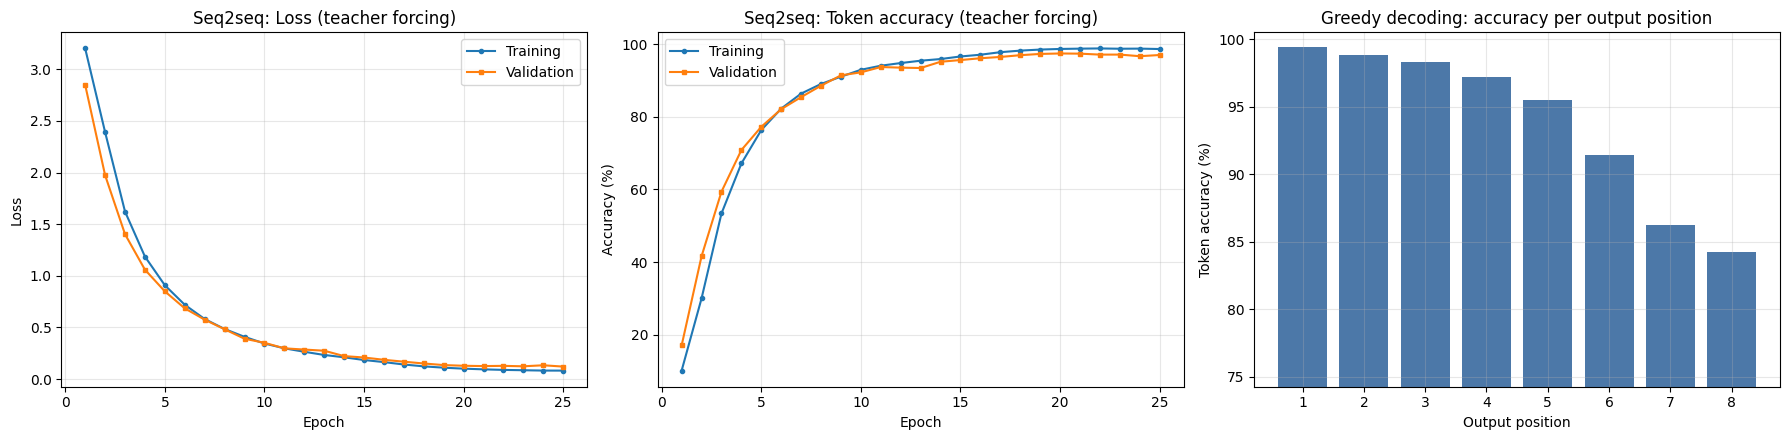

Per-position token accuracy (%): [99.44, 98.83, 98.28, 97.22, 95.5, 91.44, 86.22, 84.28]


In [30]:
# Seq2seq training/validation loss and accuracy curves, plus per-position token accuracy of the greedy decoder
ep = np.arange(1, len(s2s_hist["loss"]) + 1)
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
ax[0].plot(ep, s2s_hist["loss"], "o-", ms=3, label="Training"); ax[0].plot(ep, s2s_hist["val_loss"], "s-", ms=3, label="Validation")
ax[0].set(title="Seq2seq: Loss (teacher forcing)", xlabel="Epoch", ylabel="Loss")
ax[1].plot(ep, 100 * np.array(s2s_hist["accuracy"]), "o-", ms=3, label="Training")
ax[1].plot(ep, 100 * np.array(s2s_hist["val_accuracy"]), "s-", ms=3, label="Validation")
ax[1].set(title="Seq2seq: Token accuracy (teacher forcing)", xlabel="Epoch", ylabel="Accuracy (%)")
pos_acc = 100 * correct.mean(axis=0)
ax[2].bar(np.arange(1, S2S_LEN + 1), pos_acc, color="#4C78A8")
ax[2].set(title="Greedy decoding: accuracy per output position", xlabel="Output position", ylabel="Token accuracy (%)",
          ylim=(max(0, pos_acc.min() - 10), 100.5))
for a in ax[:2]:
    a.legend()
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); save_fig("plot_seq2seq_curves"); plt.show()
print("Per-position token accuracy (%):", np.round(pos_acc, 2).tolist())

In [31]:
# Consolidated results table (HAR models + video models) and separate seq2seq table; saved as CSV in /kaggle/working
cols = ["Accuracy (%)", "Macro Precision (%)", "Macro Recall (%)", "Macro F1 (%)", "Parameters", "Training Time (s)"]
all_res = {**{k: results[k] for k in RNN_LAYERS}, **{f"CNN–{k}": vresults[k] for k in vresults}}
consolidated = pd.DataFrame(all_res).T[cols]
print("Consolidated results:"); display(consolidated.round(2))

s2s_table = pd.DataFrame({"Token Accuracy (%)": [token_acc], "Sequence Accuracy (%)": [seq_acc],
                          "Final Training Loss": [s2s_hist["loss"][-1]], "Final Validation Loss": [s2s_hist["val_loss"][-1]],
                          "Parameters": [n_trainable(s2s)], "Training Time (s)": [s2s_time]},
                         index=["Encoder–Decoder LSTM"])
print("Sequence-to-sequence results:"); display(s2s_table.round(4))

consolidated.to_csv(f"{WORK_DIR}/results_consolidated.csv")
s2s_table.to_csv(f"{WORK_DIR}/results_seq2seq.csv")
seq_f1.to_csv(f"{WORK_DIR}/results_sequence_length_f1.csv")

Consolidated results:


,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
RNN,83.55,82.87,82.48,82.50,1974.0,27.93
LSTM,94.81,95.37,95.03,94.92,6006.0,22.26
GRU,98.48,98.65,98.50,98.53,4758.0,21.69
CNN–LSTM,88.00,88.35,88.00,87.54,168229.0,6.33
CNN–GRU,92.00,91.96,92.00,91.89,126309.0,6.25


Sequence-to-sequence results:


,Token Accuracy (%),Sequence Accuracy (%),Final Training Loss,Final Validation Loss,Parameters,Training Time (s)
Encoder–Decoder LSTM,93.9028,81.0,0.0821,0.1211,53663,30.9311


RNN  16 units | F1 72.21% | params 790 | time 27.0s
RNN  32 units | F1 82.50% | params 1974 | time 27.9s
RNN  64 units | F1 84.25% | params 5878 | time 27.6s
LSTM 16 units | F1 92.71% | params 2038 | time 21.9s
LSTM 32 units | F1 94.92% | params 6006 | time 22.3s
LSTM 64 units | F1 96.86% | params 20086 | time 22.0s
GRU  16 units | F1 96.37% | params 1670 | time 22.0s
GRU  32 units | F1 98.53% | params 4758 | time 21.7s
GRU  64 units | F1 96.64% | params 15542 | time 21.8s
RNN  stacked 2×32 | F1 86.60% | params 4054 | time 44.8s
LSTM stacked 2×32 | F1 97.07% | params 14326 | time 31.8s
GRU  stacked 2×32 | F1 97.51% | params 11094 | time 31.1s
LSTM unidirectional | F1 94.92% | params 6006 | time 22.3s
LSTM bidirectional | F1 94.87% | params 11894 | time 31.8s


,Exercise,Model,Setting,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,Recurrent units,RNN,16 units,74.24,72.61,72.44,72.21,790,26.96
1,Recurrent units,RNN,32 units,83.55,82.87,82.48,82.50,1974,27.93
2,Recurrent units,RNN,64 units,85.06,85.05,84.22,84.25,5878,27.57
3,Recurrent units,LSTM,16 units,92.64,92.73,92.93,92.71,2038,21.89
4,Recurrent units,LSTM,32 units,94.81,95.37,95.03,94.92,6006,22.26
5,Recurrent units,LSTM,64 units,96.75,96.85,96.88,96.86,20086,21.99
6,Recurrent units,GRU,16 units,96.32,96.87,96.29,96.37,1670,21.95
7,Recurrent units,GRU,32 units,98.48,98.65,98.50,98.53,4758,21.69
8,Recurrent units,GRU,64 units,96.54,97.28,96.62,96.64,15542,21.81
9,Stacked layers,RNN,2 × 32,87.23,87.37,86.81,86.60,4054,44.83


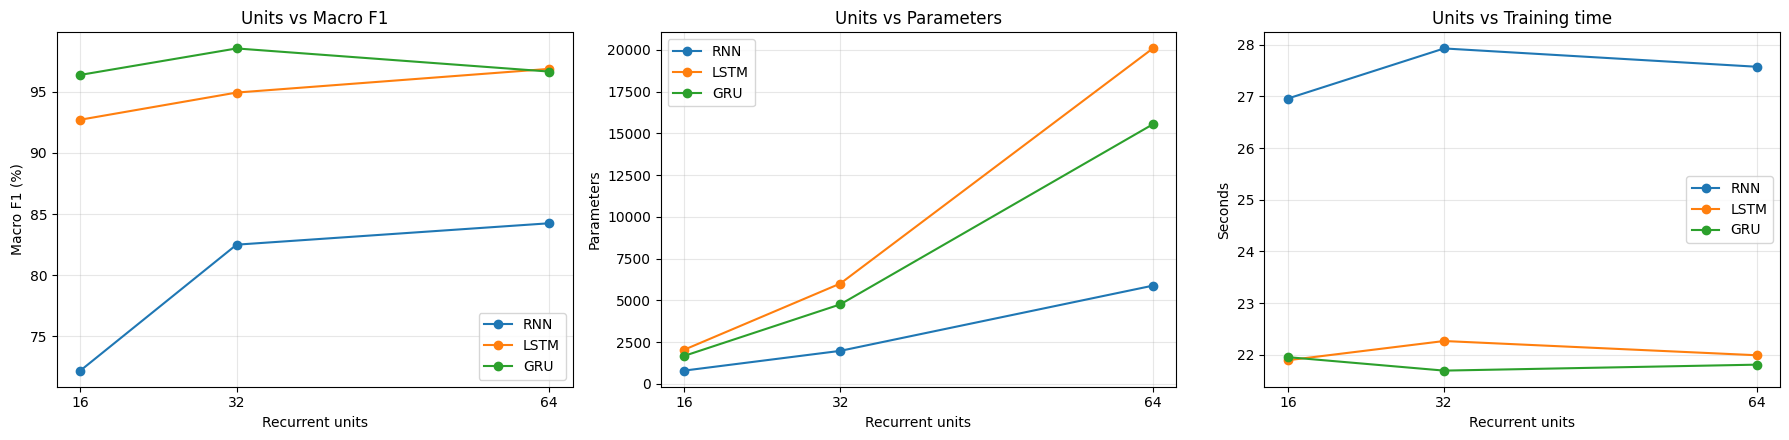

In [32]:
# Additional exercises 1–4: units 16/32/64, two stacked recurrent layers, and bidirectional vs unidirectional LSTM (set RUN_EXTRA=False to skip)
RUN_EXTRA = True
if RUN_EXTRA:
    extra = []
    for k in RNN_LAYERS:
        for u in [16, 32, 64]:
            r = results[k] if u == UNITS else train_eval(k, units=u)[3]
            extra.append({"Exercise": "Recurrent units", "Model": k, "Setting": f"{u} units", **r})
            print(f"{k:<4} {u:>2} units | F1 {r['Macro F1 (%)']:.2f}% | params {r['Parameters']} | time {r['Training Time (s)']:.1f}s")
    for k in RNN_LAYERS:
        r = train_eval(k, stacked=True)[3]
        extra.append({"Exercise": "Stacked layers", "Model": k, "Setting": "2 × 32", **r})
        print(f"{k:<4} stacked 2×32 | F1 {r['Macro F1 (%)']:.2f}% | params {r['Parameters']} | time {r['Training Time (s)']:.1f}s")
    for bidir in [False, True]:
        r = results["LSTM"] if not bidir else train_eval("LSTM", bidir=True)[3]
        extra.append({"Exercise": "Direction", "Model": "LSTM", "Setting": "Bidirectional" if bidir else "Unidirectional", **r})
        print(f"LSTM {'bi' if bidir else 'uni'}directional | F1 {r['Macro F1 (%)']:.2f}% | params {r['Parameters']} | time {r['Training Time (s)']:.1f}s")
    extra_df = pd.DataFrame(extra)
    display(extra_df.round(2))
    extra_df.to_csv(f"{WORK_DIR}/results_additional_exercises.csv", index=False)

    units_df = extra_df[extra_df.Exercise == "Recurrent units"]
    fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
    for k in RNN_LAYERS:
        d = units_df[units_df.Model == k]
        u = [16, 32, 64]
        ax[0].plot(u, d["Macro F1 (%)"], "o-", label=k)
        ax[1].plot(u, d["Parameters"], "o-", label=k)
        ax[2].plot(u, d["Training Time (s)"], "o-", label=k)
    for a, t, yl in zip(ax, ["Units vs Macro F1", "Units vs Parameters", "Units vs Training time"], ["Macro F1 (%)", "Parameters", "Seconds"]):
        a.set(title=t, xlabel="Recurrent units", ylabel=yl, xticks=[16, 32, 64]); a.legend(); a.grid(alpha=0.3)
    plt.tight_layout(); save_fig("plot_extra_units_study"); plt.show()

In [33]:
# Bundle all figures into one zip for download from the Output panel
shutil.make_archive(f"{WORK_DIR}/exp6_figures", "zip", FIG_DIR)
print("Figures:", sorted(os.listdir(FIG_DIR)))
print("Download: /kaggle/working/exp6_figures.zip and results_*.csv")

Figures: ['plot1_sensor_signals.jpg', 'plot2_3_curves_gru.jpg', 'plot2_3_curves_lstm.jpg', 'plot2_3_curves_rnn.jpg', 'plot4_confusion_gru.jpg', 'plot4_confusion_lstm.jpg', 'plot4_confusion_rnn.jpg', 'plot5_model_comparison.jpg', 'plot6_sequence_length.jpg', 'plot7_video_frames.jpg', 'plot8_video_curves_cnn_gru.jpg', 'plot8_video_curves_cnn_lstm.jpg', 'plot9_video_confusion_cnn_gru.jpg', 'plot9_video_confusion_cnn_lstm.jpg', 'plot_extra_bptt_gradient_decay.jpg', 'plot_extra_units_study.jpg', 'plot_seq2seq_curves.jpg']
Download: /kaggle/working/exp6_figures.zip and results_*.csv
